<a href="https://colab.research.google.com/github/nikita-boiko/PySpark_project/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
# Возможно, после входа в аккаунт вам потребуется заново выполнить код в этой ячейке.
kagglehub.login()
path = kagglehub.competition_download('riiid-test-answer-prediction')

100%|██████████| 1.29G/1.29G [00:13<00:00, 99.3MB/s]

Extracting files...


In [5]:
from pyspark.sql import SparkSession
import os
os.environ['PYARROW_IGNORE_TIMEZONE'] = '1'

spark = SparkSession.builder.getOrCreate()
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
spark

df = spark.read.csv('/root/.cache/kagglehub/competitions/riiid-test-answer-\
prediction/train.csv', header=True, inferSchema=True)

df.printSchema()


root
 |-- row_id: integer (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- content_id: integer (nullable = true)
 |-- content_type_id: integer (nullable = true)
 |-- task_container_id: integer (nullable = true)
 |-- user_answer: integer (nullable = true)
 |-- answered_correctly: integer (nullable = true)
 |-- prior_question_elapsed_time: double (nullable = true)
 |-- prior_question_had_explanation: boolean (nullable = true)



In [6]:
df.show()

+------+---------+-------+----------+---------------+-----------------+-----------+------------------+---------------------------+------------------------------+
|row_id|timestamp|user_id|content_id|content_type_id|task_container_id|user_answer|answered_correctly|prior_question_elapsed_time|prior_question_had_explanation|
+------+---------+-------+----------+---------------+-----------------+-----------+------------------+---------------------------+------------------------------+
|     0|        0|    115|      5692|              0|                1|          3|                 1|                       NULL|                          NULL|
|     1|    56943|    115|      5716|              0|                2|          2|                 1|                    37000.0|                         false|
|     2|   118363|    115|       128|              0|                0|          0|                 1|                    55000.0|                         false|
|     3|   131167|    115|  

In [10]:
from pyspark.sql.types import IntegerType

df = df.withColumn('prior_question_had_explanation', df['prior_question_had_explanation'].cast(IntegerType()))
df.printSchema()

root
 |-- row_id: integer (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- content_id: integer (nullable = true)
 |-- content_type_id: integer (nullable = true)
 |-- task_container_id: integer (nullable = true)
 |-- user_answer: integer (nullable = true)
 |-- answered_correctly: integer (nullable = true)
 |-- prior_question_elapsed_time: double (nullable = true)
 |-- prior_question_had_explanation: integer (nullable = true)



In [13]:
spark.conf.set("spark.sql.ansi.enabled", "false")
df.pandas_api().isna().mean()

row_id                            0.000000
timestamp                         0.000000
user_id                           0.000000
content_id                        0.000000
content_type_id                   0.000000
task_container_id                 0.000000
user_answer                       0.000000
answered_correctly                0.000000
prior_question_elapsed_time       0.023230
prior_question_had_explanation    0.003877
dtype: float64

In [14]:
df = df.dropna()
df.pandas_api().isna().sum()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/generic.py:1373: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  warnings.warn(


row_id                            0
timestamp                         0
user_id                           0
content_id                        0
content_type_id                   0
task_container_id                 0
user_answer                       0
answered_correctly                0
prior_question_elapsed_time       0
prior_question_had_explanation    0
dtype: int64

In [17]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd

vector_col = 'corr_features'
assembler = VectorAssembler(inputCols=df.columns, outputCol=vector_col)
df_vector  = assembler.transform(df).select(vector_col)

matrix_row = Correlation.corr(df_vector, vector_col).collect()[0]

corr_matrix = matrix_row[0].toArray()

corr_matrix_df = pd.DataFrame(data=corr_matrix, columns=df.columns, index=df.columns)

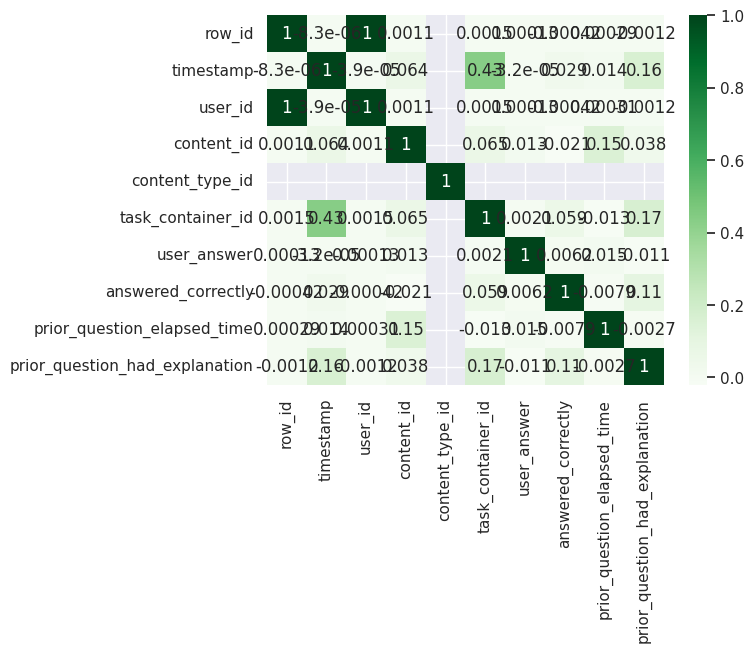

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

sns.heatmap(corr_matrix_df,
            xticklabels=corr_matrix_df.columns.values,
            yticklabels=corr_matrix_df.columns.values, cmap='Greens', annot=True)
plt.show()